# Tarea 1

**Autor:** Alejandro Zarate Macias  

**Curso:** Redes Neuronales Profundas (NN)

**Fecha:** 9 de Marzo 2026

---

## Introducción

Estos ejercicios tienen como objetivo revisar algunos conceptos básicos de aprendizaje automático y redes neuronales, así como practicar la implementación de modelos simples utilizando Python y sus librerías.

---

## Pre-requisitos

- Python 3.9 o superior
- Librerías:
    - numpy
    - matplotlib
    - notebook
    - pandas
    - scikit-learn
    - torch

---

# Problema 2

Haga un script en Python para calcular el autovalor de módulo máximo y su autovector correspondiente de una matriz simétrica $A \in \mathbb{R}^{n\times n}$. Use Pytorch en lugar de los paquetes Numpy/Scipy. Use el método de la potencia, descrito (por ejemplo) en `Matrix Computations`, en la sección 8.2.1. A continuación, pruebe su programa con la siguiente matriz


$$
\left(
\begin{array}{rrrr}
-1.6407 & 1.0814 & 1.2014 & 1.1539 \\
1.0814 & 4.1573 & 7.4035 & -1.0463 \\
1.2014 & 7.4035 & 2.7890 & -1.5737 \\
1.1539 & -1.0463 & -1.5737 & 8.6944
\end{array}
\right)
$$

In [1]:
# Librerias necesarias
import torch

In [2]:
# Definir la matriz simetrica
A = torch.tensor([
    [-1.6407,  1.0814,  1.2014,  1.1539],
    [ 1.0814,  4.1573,  7.4035, -1.0463],
    [ 1.2014,  7.4035,  2.7890, -1.5737],
    [ 1.1539, -1.0463, -1.5737,  8.6944]
], dtype=torch.float64)
A

tensor([[-1.6407,  1.0814,  1.2014,  1.1539],
        [ 1.0814,  4.1573,  7.4035, -1.0463],
        [ 1.2014,  7.4035,  2.7890, -1.5737],
        [ 1.1539, -1.0463, -1.5737,  8.6944]], dtype=torch.float64)

In [3]:
# Metodo de la potencia
max_iter = 1000
tol = 1e-10

q = torch.randn(A.shape[0], dtype=torch.float64)
q = q / torch.norm(q)

for k in range(max_iter):
    z = A @ q
    q_new = z / torch.norm(z)
    eigenvalue = q_new @ A @ q_new

    # Criterio de convergencia
    if torch.norm(q_new - q) < tol:
        print(f"Convergencia en iteracion {k+1}")
        break
    q = q_new

eigenvalue = q_new @ A @ q_new
eigenvector = q_new

print(f"Autovalor de modulo maximo: {eigenvalue.item():.6f}")
print(f"Autovector correspondiente: {eigenvector}")

Convergencia en iteracion 52
Autovalor de modulo maximo: 12.000050
Autovector correspondiente: tensor([ 0.0645,  0.6416,  0.6041, -0.4682], dtype=torch.float64)


In [4]:
# Verificacion con torch.linalg.eigh
eigenvalues, eigenvectors = torch.linalg.eigh(A)
idx = torch.argmax(torch.abs(eigenvalues))
print(f"\nVerificacion (torch.linalg.eigh):")
print(f"Autovalor de modulo maximo: {eigenvalues[idx].item():.6f}")
print(f"Autovector correspondiente: {eigenvectors[:, idx]}")


Verificacion (torch.linalg.eigh):
Autovalor de modulo maximo: 12.000050
Autovector correspondiente: tensor([-0.0645, -0.6416, -0.6041,  0.4682], dtype=torch.float64)


---

# Problema 3

Haga un script en Python usando Pytorch para minimizar la función de `Rosenbrock` para $n = 10$ utilizando el método de Newton. Grafique cómo el error disminuye a medida que el algoritmo itera.


In [5]:
# Librerias necesarias
import torch
import matplotlib.pyplot as plt

In [6]:
# Funcion de Rosenbrock
def rosenbrock(x):
    return torch.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (x[:-1] - 1.0)**2)

In [7]:
# Parametros
n = 10
max_iter = 200
tol = 1e-10

# Punto inicial
x = torch.zeros(n, dtype=torch.float64, requires_grad=True)


In [8]:
# Iteracion del metodo de Newton

errors = []

for k in range(max_iter):
    f = rosenbrock(x)
    errors.append(f.item())

    # Gradiente
    g = torch.autograd.grad(f, x, create_graph=True)[0]

    # Hessiana
    H = torch.zeros(n, n, dtype=torch.float64)
    for i in range(n):
        H[i] = torch.autograd.grad(g[i], x, retain_graph=True)[0]

    # Paso de Newton: resolver H * d = -g
    d = torch.linalg.solve(H, -g.detach())

    # Actualizar x
    x = (x.detach() + d).requires_grad_(True)

    if torch.norm(g).item() < tol:
        print(f"Convergencia en iteracion {k+1}")
        break

print(f"Valor minimo: {rosenbrock(x).item():.10f}")
print(f"Norma del gradiente final: {torch.norm(torch.autograd.grad(rosenbrock(x), x)[0]).item():.2e}")

Convergencia en iteracion 17
Valor minimo: 0.0000000000
Norma del gradiente final: 0.00e+00


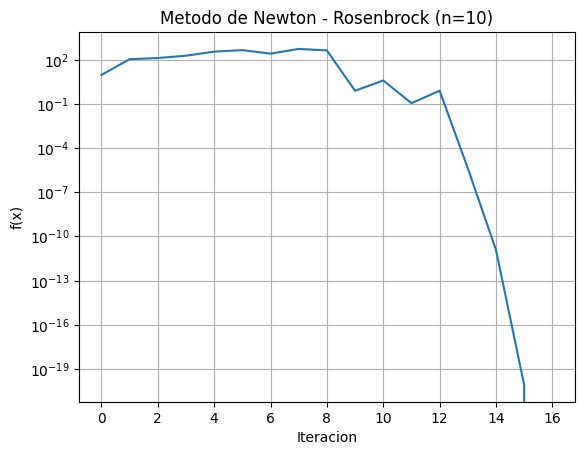

In [9]:
# Grafica del error vs iteraciones
plt.figure()
plt.semilogy(errors)
plt.xlabel("Iteracion")
plt.ylabel("f(x)")
plt.title("Metodo de Newton - Rosenbrock (n=10)")
plt.grid(True)
plt.show()

---

# Problema 4

Haga un script en Python usando Pytorch para minimizar la función de `Rosenbrock` para $n = 10$ utilizando el método BFGS. Grafique cómo el error disminuye a medida que el algoritmo itera.

In [10]:
# Librerias necesarias
import torch
import matplotlib.pyplot as plt

In [11]:
# Funcion de Rosenbrock
def rosenbrock(x):
    return torch.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (x[:-1] - 1.0)**2)

In [12]:
# Parametros
n = 10
max_iter = 500
tol = 1e-10

# Punto inicial
x = torch.zeros(n, dtype=torch.float64, requires_grad=True)

# Inicializar la aproximacion de la inversa de la Hessiana como identidad
B_inv = torch.eye(n, dtype=torch.float64)

In [13]:
# Iteracion del metodo BFGS
errors = []

for k in range(max_iter):
    f = rosenbrock(x)
    errors.append(f.item())

    # Gradiente
    g = torch.autograd.grad(f, x)[0].detach()

    if torch.norm(g).item() < tol:
        print(f"Convergencia en iteracion {k+1}")
        break

    # Direccion de descenso BFGS
    d = -B_inv @ g

    # Busqueda de linea por backtracking (condicion de Armijo)
    alpha = 1.0
    c1 = 1e-4
    rho = 0.5
    x_new = (x.detach() + alpha * d).requires_grad_(True)
    while rosenbrock(x_new).item() > f.item() + c1 * alpha * g @ d:
        alpha *= rho
        x_new = (x.detach() + alpha * d).requires_grad_(True)

    # Calcular s y y para la actualizacion BFGS
    s = alpha * d
    g_new = torch.autograd.grad(rosenbrock(x_new), x_new)[0].detach()
    y = g_new - g

    # Actualizacion de la inversa de la Hessiana (formula BFGS)
    sy = s @ y
    if sy > 1e-12:
        rho_k = 1.0 / sy
        I = torch.eye(n, dtype=torch.float64)
        V = I - rho_k * torch.outer(s, y)
        B_inv = V @ B_inv @ V.T + rho_k * torch.outer(s, s)

    x = x_new

print(f"Valor minimo: {rosenbrock(x).item():.10f}")
print(f"Norma del gradiente final: {torch.norm(torch.autograd.grad(rosenbrock(x), x)[0]).item():.2e}")

Convergencia en iteracion 74
Valor minimo: 0.0000000000
Norma del gradiente final: 9.12e-11


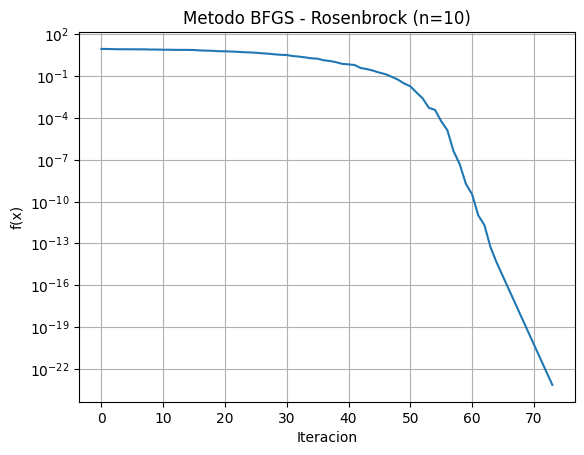

In [14]:
# Grafica del error vs iteraciones
plt.figure()
plt.semilogy(errors)
plt.xlabel("Iteracion")
plt.ylabel("f(x)")
plt.title("Metodo BFGS - Rosenbrock (n=10)")
plt.grid(True)
plt.show()


---

# Problema 5

Haga un script en Python usando Pytorch para minimizar la función de `Rosenbrock` para $n = 10$ utilizando el método de Adam. Grafque cómo el error disminuye a medida que el algoritmo itera.

In [15]:
# Librerias necesarias
import torch
import matplotlib.pyplot as plt

In [16]:
# Funcion de Rosenbrock
def rosenbrock(x):
    return torch.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (x[:-1] - 1.0)**2)

In [17]:
# Parametros
n = 10
max_iter = 50000
lr = 0.001

# Punto inicial
x = torch.zeros(n, dtype=torch.float64, requires_grad=True)

# Optimizador Adam
optimizer = torch.optim.Adam([x], lr=lr)

In [18]:
# Iteracion del metodo Adam
errors = []

for k in range(max_iter):
    optimizer.zero_grad()
    f = rosenbrock(x)
    errors.append(f.item())
    f.backward()
    optimizer.step()

print(f"Valor minimo: {rosenbrock(x).item():.10f}")
g = torch.autograd.grad(rosenbrock(x), x)[0]
print(f"Norma del gradiente final: {torch.norm(g).item():.2e}")

Valor minimo: 0.0000028062
Norma del gradiente final: 9.43e-02


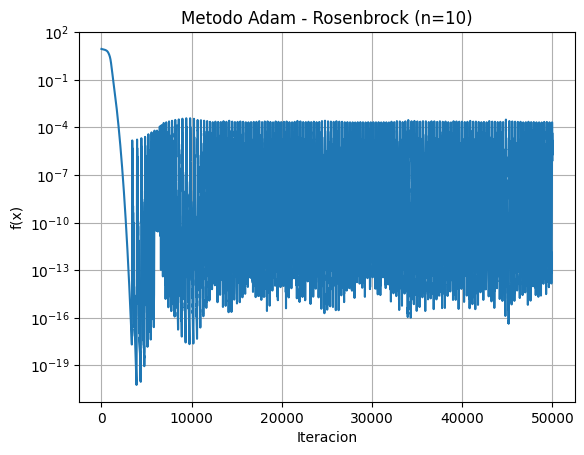

In [19]:
# Grafica del error vs iteraciones
plt.figure()
plt.semilogy(errors)
plt.xlabel("Iteracion")
plt.ylabel("f(x)")
plt.title("Metodo Adam - Rosenbrock (n=10)")
plt.grid(True)
plt.show()